# Proyek Predictive Analytics - Prediksi Tingkat Nilai Siswa

- **Nama:** Nur Adilah
- **Email:** nuradilah@students.usu.ac.id
- **ID Dicoding:** MC319D5X0793 NUR ADILAH

###Pendahuluan

Setiap institusi pendidikan memiliki tantangan dalam memastikan siswa mampu menyelesaikan pendidikannya dengan baik. Namun, tidak semua siswa memiliki latar belakang dan kebiasaan belajar yang mendukung keberhasilan akademik mereka.

Melalui proyek ini, kita ingin memprediksi memprediksi tingkat atau kategori nilai akhir siswa (GradeClass 0-4). Menggunakan berbagai faktor seperti usia, jenis kelamin, waktu belajar mingguan, absensi, dan dukungan orang tua. Dengan memanfaatkan algoritma machine learning, sekolah atau guru dapat mendeteksi siswa yang berisiko tidak lulus lebih awal dan mengambil langkah preventif.

Model prediksi kelulusan ini dapat membantu:
- Guru memberikan perhatian dan bimbingan yang lebih sesuai kepada siswa berdasarkan potensi tingkat nilai mereka.
- Sekolah merancang program intervensi, dukungan, atau pengayaan yang ditargetkan untuk kelompok siswa dengan tingkat nilai tertentu.
- Orang tua lebih memahami posisi akademik anak dan memberikan dukungan yang diperlukan.

### Tujuan

- Membangun model membangun model klasifikasi multi-kelas yang akurat untuk memprediksi GradeClass siswa, memungkinkan deteksi dini potensi performa akademik di berbagai tingkatan.

# Data Understanding

Dataset yang digunakan dalam proyek ini adalah `Student_performance.csv` yang berisi data performa akademik siswa. Tujuan dari tahap ini adalah untuk memahami struktur dataset, mengetahui jenis data, dan melihat distribusi data secara umum.


**Data Loading**

Melakukan load dataset, kemudian import library pandas untuk dapat membaca file datanya. Dataset yang akan kita gunakan bernama Student_performance.csv ingkat nilai akhir siswa (multi-kelas) menggunakan GradeClass. Dataset ini berasal dari kaggle "Students Performance Dataset"

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# load dataset
student = pd.read_csv('/content/Student_performance.csv')
student

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0



- ada 2.392 baris dalam dataset.
- Terdapat 15 kolom yaitu: StudentID, Age, Gender (0 = perempuan dan 1 = laki-laki), Ethnicity, ParentalEducation (Tingkat pendidikan orang tua), StudyTimeWeekly (Waktu belajar mingguan siswa (dalam jam)), Absences (Jumlah ketidakhadiran), Tutoring (Mengikuti les tambahan (0 = tidak, 1 = ya)), ParentalSupport (Dukungan orang tua (0 = tidak, 1 = ya)), Extracurricular,	Sports,	Music,	Volunteering,	GPA (Nilai rata-rata akademik siswa),	GradeClass (Kategori nilai akhir (0–4)).

# Exploratory Data Analysis - Deskripsi Variabel

In [67]:
# cek informasi pada dataset
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


Dari output terlihat bahwa:

- Terdapat 3 kolom dengan tipe data float64 yaitu: StudyTimeWeekly, GPA, dan GradeClass. Namun baiknya kolom GradeClass dibuah menjaid tipe data integer karena pada kolom tersebut isinya menunjukkan kelas diskrit (seperti 1.0, 2.0, dst), sehingga lebih tepat jika dikonversi ke tipe int.
- Terdapat 12 kolom dengan tipe data int64 yaitu: StudentID, Age, Gender, Ethnicity,	ParentalEducation, Absences,	Tutoring,	ParentalSupport,	Extracurricular,	Sports,	Music,	Volunteering.

Nah, setelah diperhatikan, terdapat beberapa kolom yang sebaiknya diubah ke tipe data kategori (category) seperti mengubah kolom GradeClass ke integer, kemudian mengidentifikasi variabel kategorikal (Gender, Ethnicity, ParentalEducation, dll).

In [68]:
student.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


**Insight:**

- Count: Semua kolom memiliki jumlah data yang sama (2392), menunjukkan tidak ada missing values.
- Mean: Rata-rata usia siswa adalah sekitar 15 - 18 tahun. Rata-rata waktu belajar mingguan sekitar 9.8 jam. Rata-rata absensi sekitar 14 kali. Rata-rata GPA sekitar 2.4.
- Std: Menunjukkan sebaran data. Usia dan GPA memiliki sebaran yang relatif kecil, sedangkan Waktu Belajar dan Absensi memiliki sebaran yang lebih besar.
- Min/Max: Menunjukkan rentang nilai. Usia siswa bervariasi dari 15 hingga 18 tahun. Waktu belajar dari 0 hingga 20 jam. Absensi dari 0 hingga 29 hari. GPA dari 0 hingga 4.
- 25%/50%/75% (Quartiles): Memberikan gambaran distribusi data. Median (50%) GPA sekitar 2.45, menunjukkan setengah siswa memiliki GPA di bawah nilai ini dan setengahnya di atas.

In [69]:
student.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


**Insight:**

- Tidak ada missing values sama sekali (0 di semua kolom).

- Artinya, kita tidak perlu mengisi atau menghapus data karena semuanya lengkap.

In [70]:
# Mengubah 'GradeClass' menjadi tipe data integer
student['GradeClass'] = student['GradeClass'].astype(int)
student['GradeClass'].unique()

array([2, 1, 4, 3, 0])

**Insight:**

Dari output tersebut array([2, 1, 4, 3, 0]) menunjukkan bahwa kolom 'GradeClass' hanya memiliki lima nilai unik, yaitu 0, 1, 2, 3, dan 4. Ini mengindikasikan bahwa "kelas nilai akhir" siswa dikategorikan ke dalam lima tingkatan yang berbeda.

In [71]:
# Mengubah tipe data 'GradeClass' ke integer
student['GradeClass'] = student['GradeClass'].astype(int)

# Ubah kolom-kolom kategorikal ke tipe kategori
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

# Ubah tipe data jadi category
student[categorical_features] = student[categorical_features].astype('category')

# Cek hasil perubahan
student.dtypes

,0
StudentID,int64
Age,int64
Gender,category
Ethnicity,category
ParentalEducation,category
StudyTimeWeekly,float64
Absences,int64
Tutoring,category
ParentalSupport,category
Extracurricular,category


**Insight:**

Berhasil mengubah tipe data pada kolom 'GradeClass' menjadi integer dan beberapa kolom lainnya seperti (Gender. Ethnicity, dll.) menjadi tipe data kategori. Ini mengkonfirmasi bahwa perubahan tipe data berhasil diterapkan, mengoptimalkan penggunaan memori dan performa, serta menyiapkan data dengan tepat untuk analisis dan pemodelan selanjutnya.

## Menangani Outliers

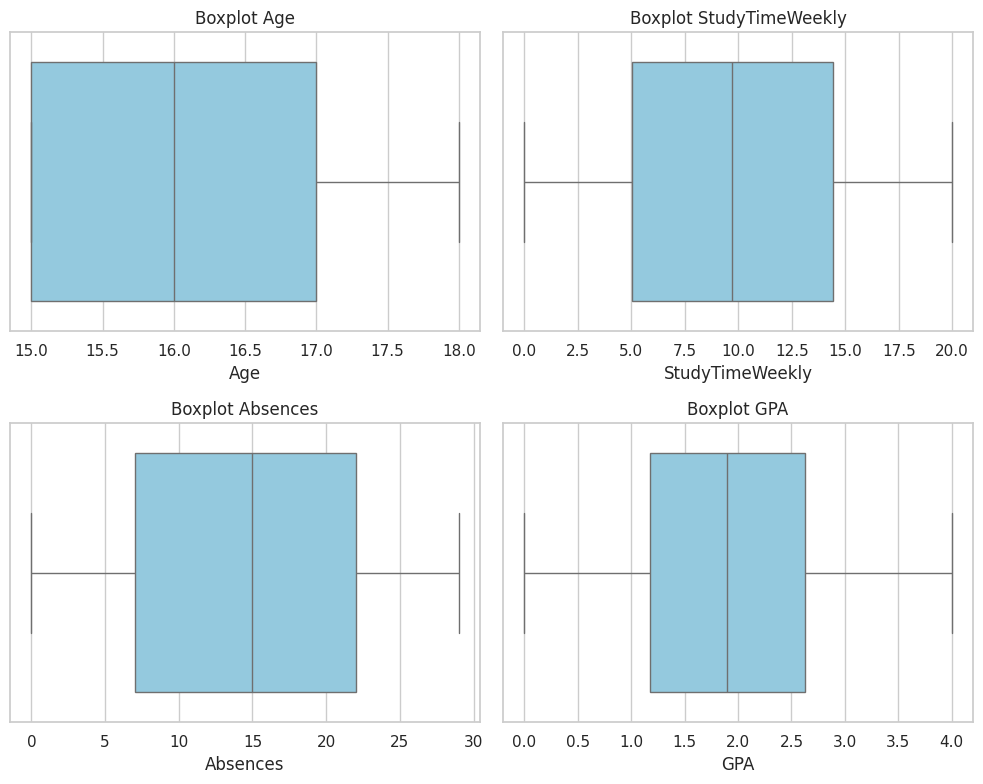

In [72]:
# cek outlier

sns.set(style="whitegrid")

numerical_features = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

plt.figure(figsize=(10, 8))
for i, col in enumerate(numerical_features):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(x=student[col], color='skyblue')
  plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

**Insight:**

Berikut hasil deteksi outlier berdasarkan boxplot:
- 'Age', tidak terlihat outlier yang signifikan. Distribusinya normal antara usia 15 - 18 tahun.
- 'StudyTimeWeekly', terlihat ada beberapa nilai ekstrem seperti di dekat 0 dan 20 jam, tapi tidak terlalu mencolok.
- 'Absences', walau agak tersebar luas, tidak ada nilai yang muncul sebagai outlier.
- 'GPA', semua data dalam rentang normal (0–4) tanpa titik mencurigakan.

## Univariate Analysis

Memisahkan fitur menjadi Numerical Features dan Categorical Features

In [73]:
# Numerical features
numerical_features = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

# Categorical Features
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']

Fitur sudah dipisah menjadi 2 yaitu numerical_features dan categorical_features.

#### Categorical Features

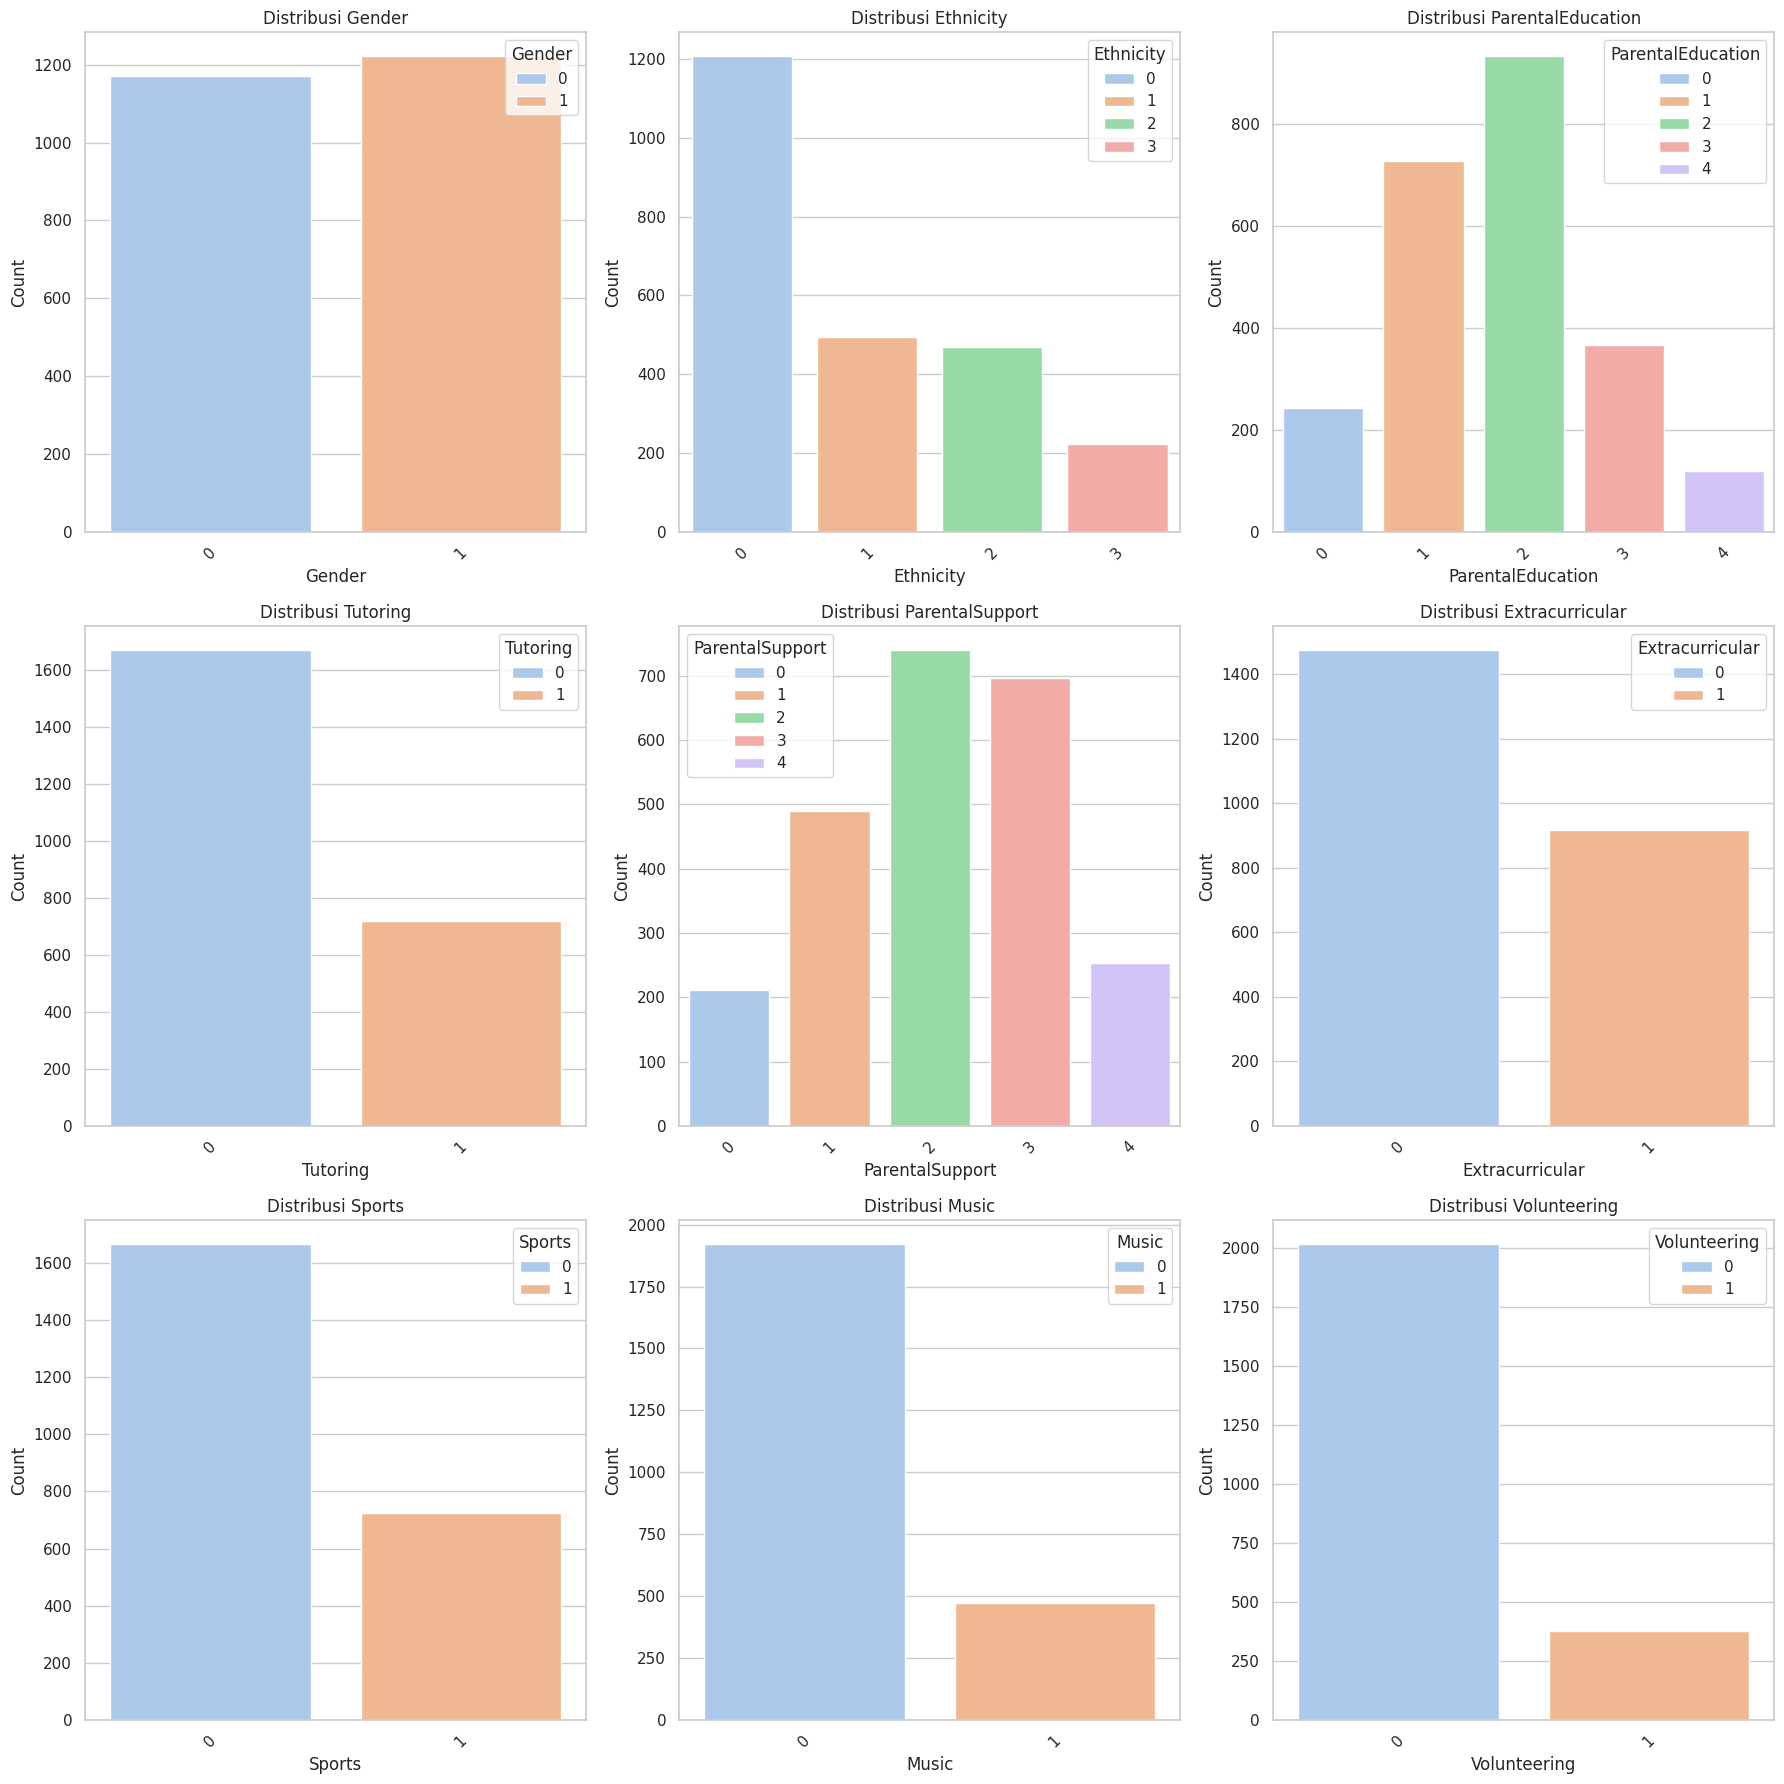

In [74]:
# Cek distribusi kolom kategorikal
categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

plt.figure(figsize=(18, 18))
for i, col in enumerate(categorical_cols):
  plt.subplot(3, 3, i + 1)
  sns.countplot(data=student, hue=col, x=col, palette="pastel")
  plt.title(f'Distribusi {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:**

Dari visualisasi distribusi kolom kategorikal memperolrh informasi:

1. Gender
  - Distribusi antara kode 0 dan 1 relatif seimbang (~50:50).
  - Bisa diasumsikan ini laki-laki vs perempuan (tapi pastikan dulu dari dokumentasi/sumber data).

2. Ethnicity
  - Kode 0 mendominasi jumlah data (~1200), sementara kategori lain (1–3) jauh lebih sedikit.
  - Potensi imbalance, perlu dipertimbangkan saat modeling.

3. ParentalEducation
  - Kategori 2 paling dominan, disusul kategori 1 dan 3.
  -Kategori 4 sangat sedikit → kemungkinan bisa digabung (jika masuk akal secara domain).

4. Tutoring
  - Mayoritas siswa tidak ikut bimbingan belajar (kode 0).
  - Ini bisa jadi fitur penting karena distribusinya tidak seimbang.

5. ParentalSupport
  - Mayoritas di kategori 2 dan 3.
  - Kategori 0 dan 4 jumlahnya cukup sedikit.

6. Extracurricular
  - Siswa yang ikut kegiatan ekstrakurikuler (kode 1) lebih sedikit dibanding yang tidak.
  - Potensi jadi fitur signifikan.

7. Sports
  - Sama seperti extracurricular — lebih banyak siswa yang tidak aktif di olahraga.

8. Music
  - Hanya sebagian kecil siswa yang terlibat di bidang musik (~20%).

9. Volunteering
  - Hanya sedikit siswa yang ikut kegiatan sukarelawan (~20%).

## Numerical features

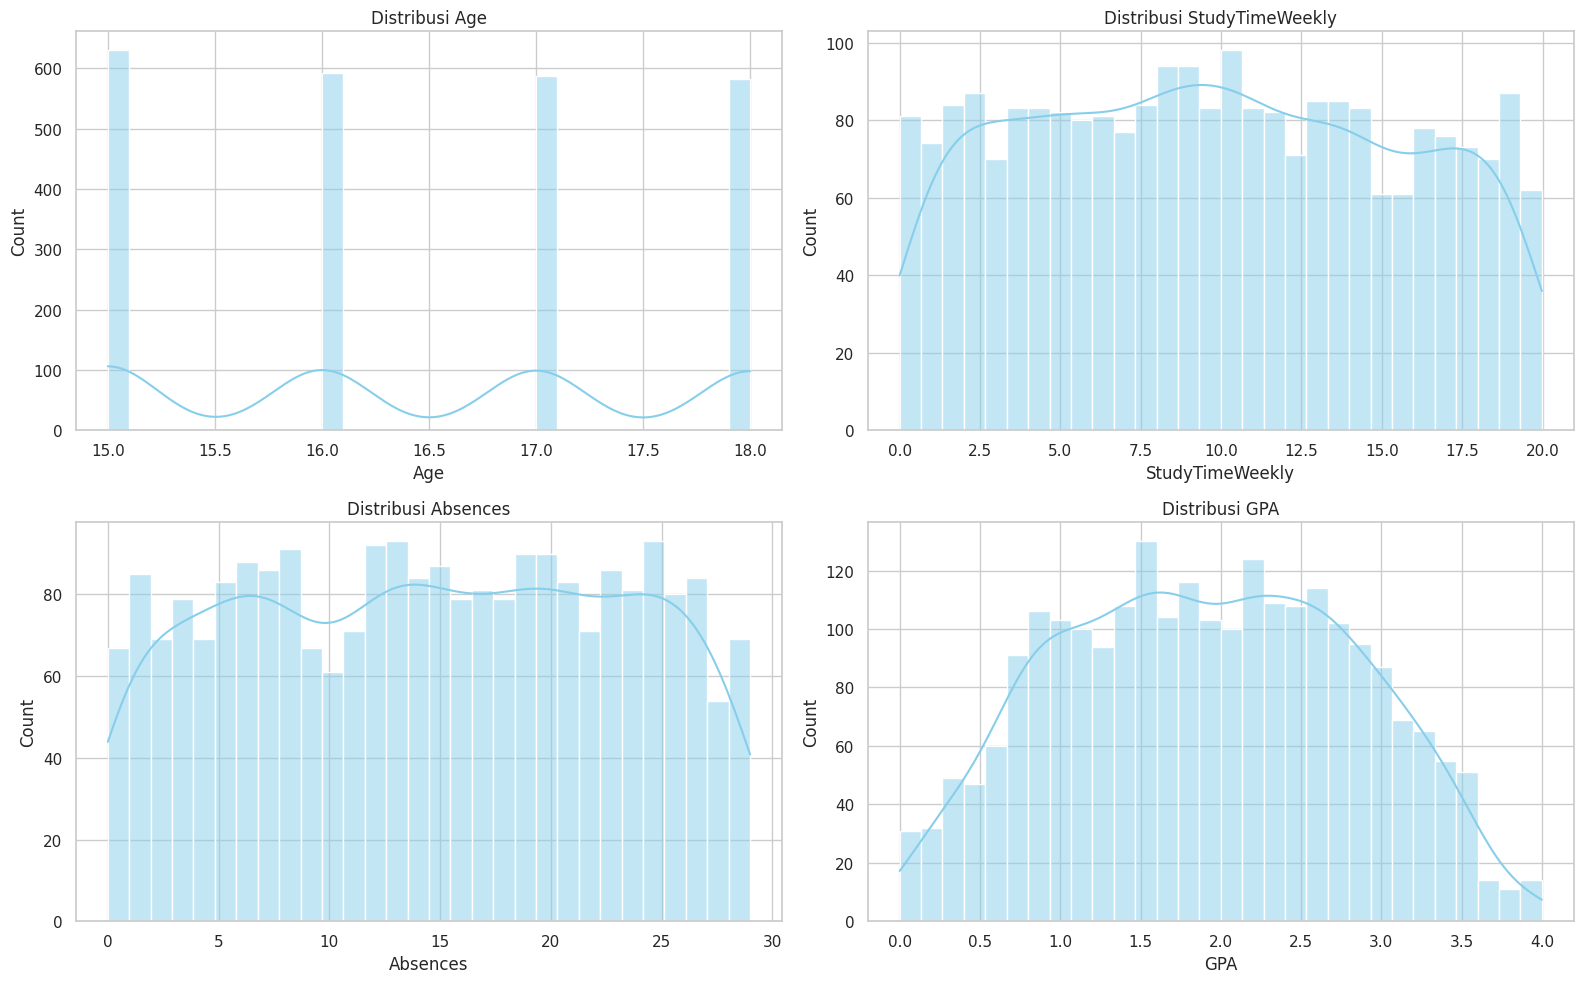

In [75]:
# cek distribusi kolom numerik
sns.set(style='whitegrid')

# membuat histogram
numerical_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(student[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

**Insight:**

Dari output diatas dapat dilihat:

1. Adge
  - Usia siswa berkisar antara 15 - 18 tahun. Hasil dari distribusi relatif merata, artinya jumlah siswa di setiap usia hampir seimbang.

2. StudyTimeWeekly
  - Rata-rata siswa menghabiskan waktu belajar mingguan di kisaran 8–12 jam.
  - Distribusinya cukup merata, sedikit condong ke tengah → tidak terlalu banyak outlier ekstrim.
  - Tidak ada lonjakan signifikan di waktu belajar sangat rendah atau tinggi.

3. Absences
  - Jumlah absensi tersebar cukup merata dari 0 sampai 29.
  - Ada sedikit tren penurunan di ujung kanan → semakin sedikit siswa yang memiliki absensi tinggi.
  - Distribusi ini terlihat sedikit miring ke kanan, artinya sebagian kecil siswa sering bolos.

4. GPA
  - GPA mayoritas siswa berada di rentang 1.0 – 3.0.
  - Distribusinya mendekati normal (bell curve), tapi sedikit condong ke kanan.
  - Sedikit siswa yang memiliki GPA mendekati 0 atau 4.0, menunjukkan nilai sangat rendah atau sangat tinggi jarang.

# Exploratory Data Analysis - Multivariate Analysis

Analisis hubungan fitur kategorikal terhadap GPA

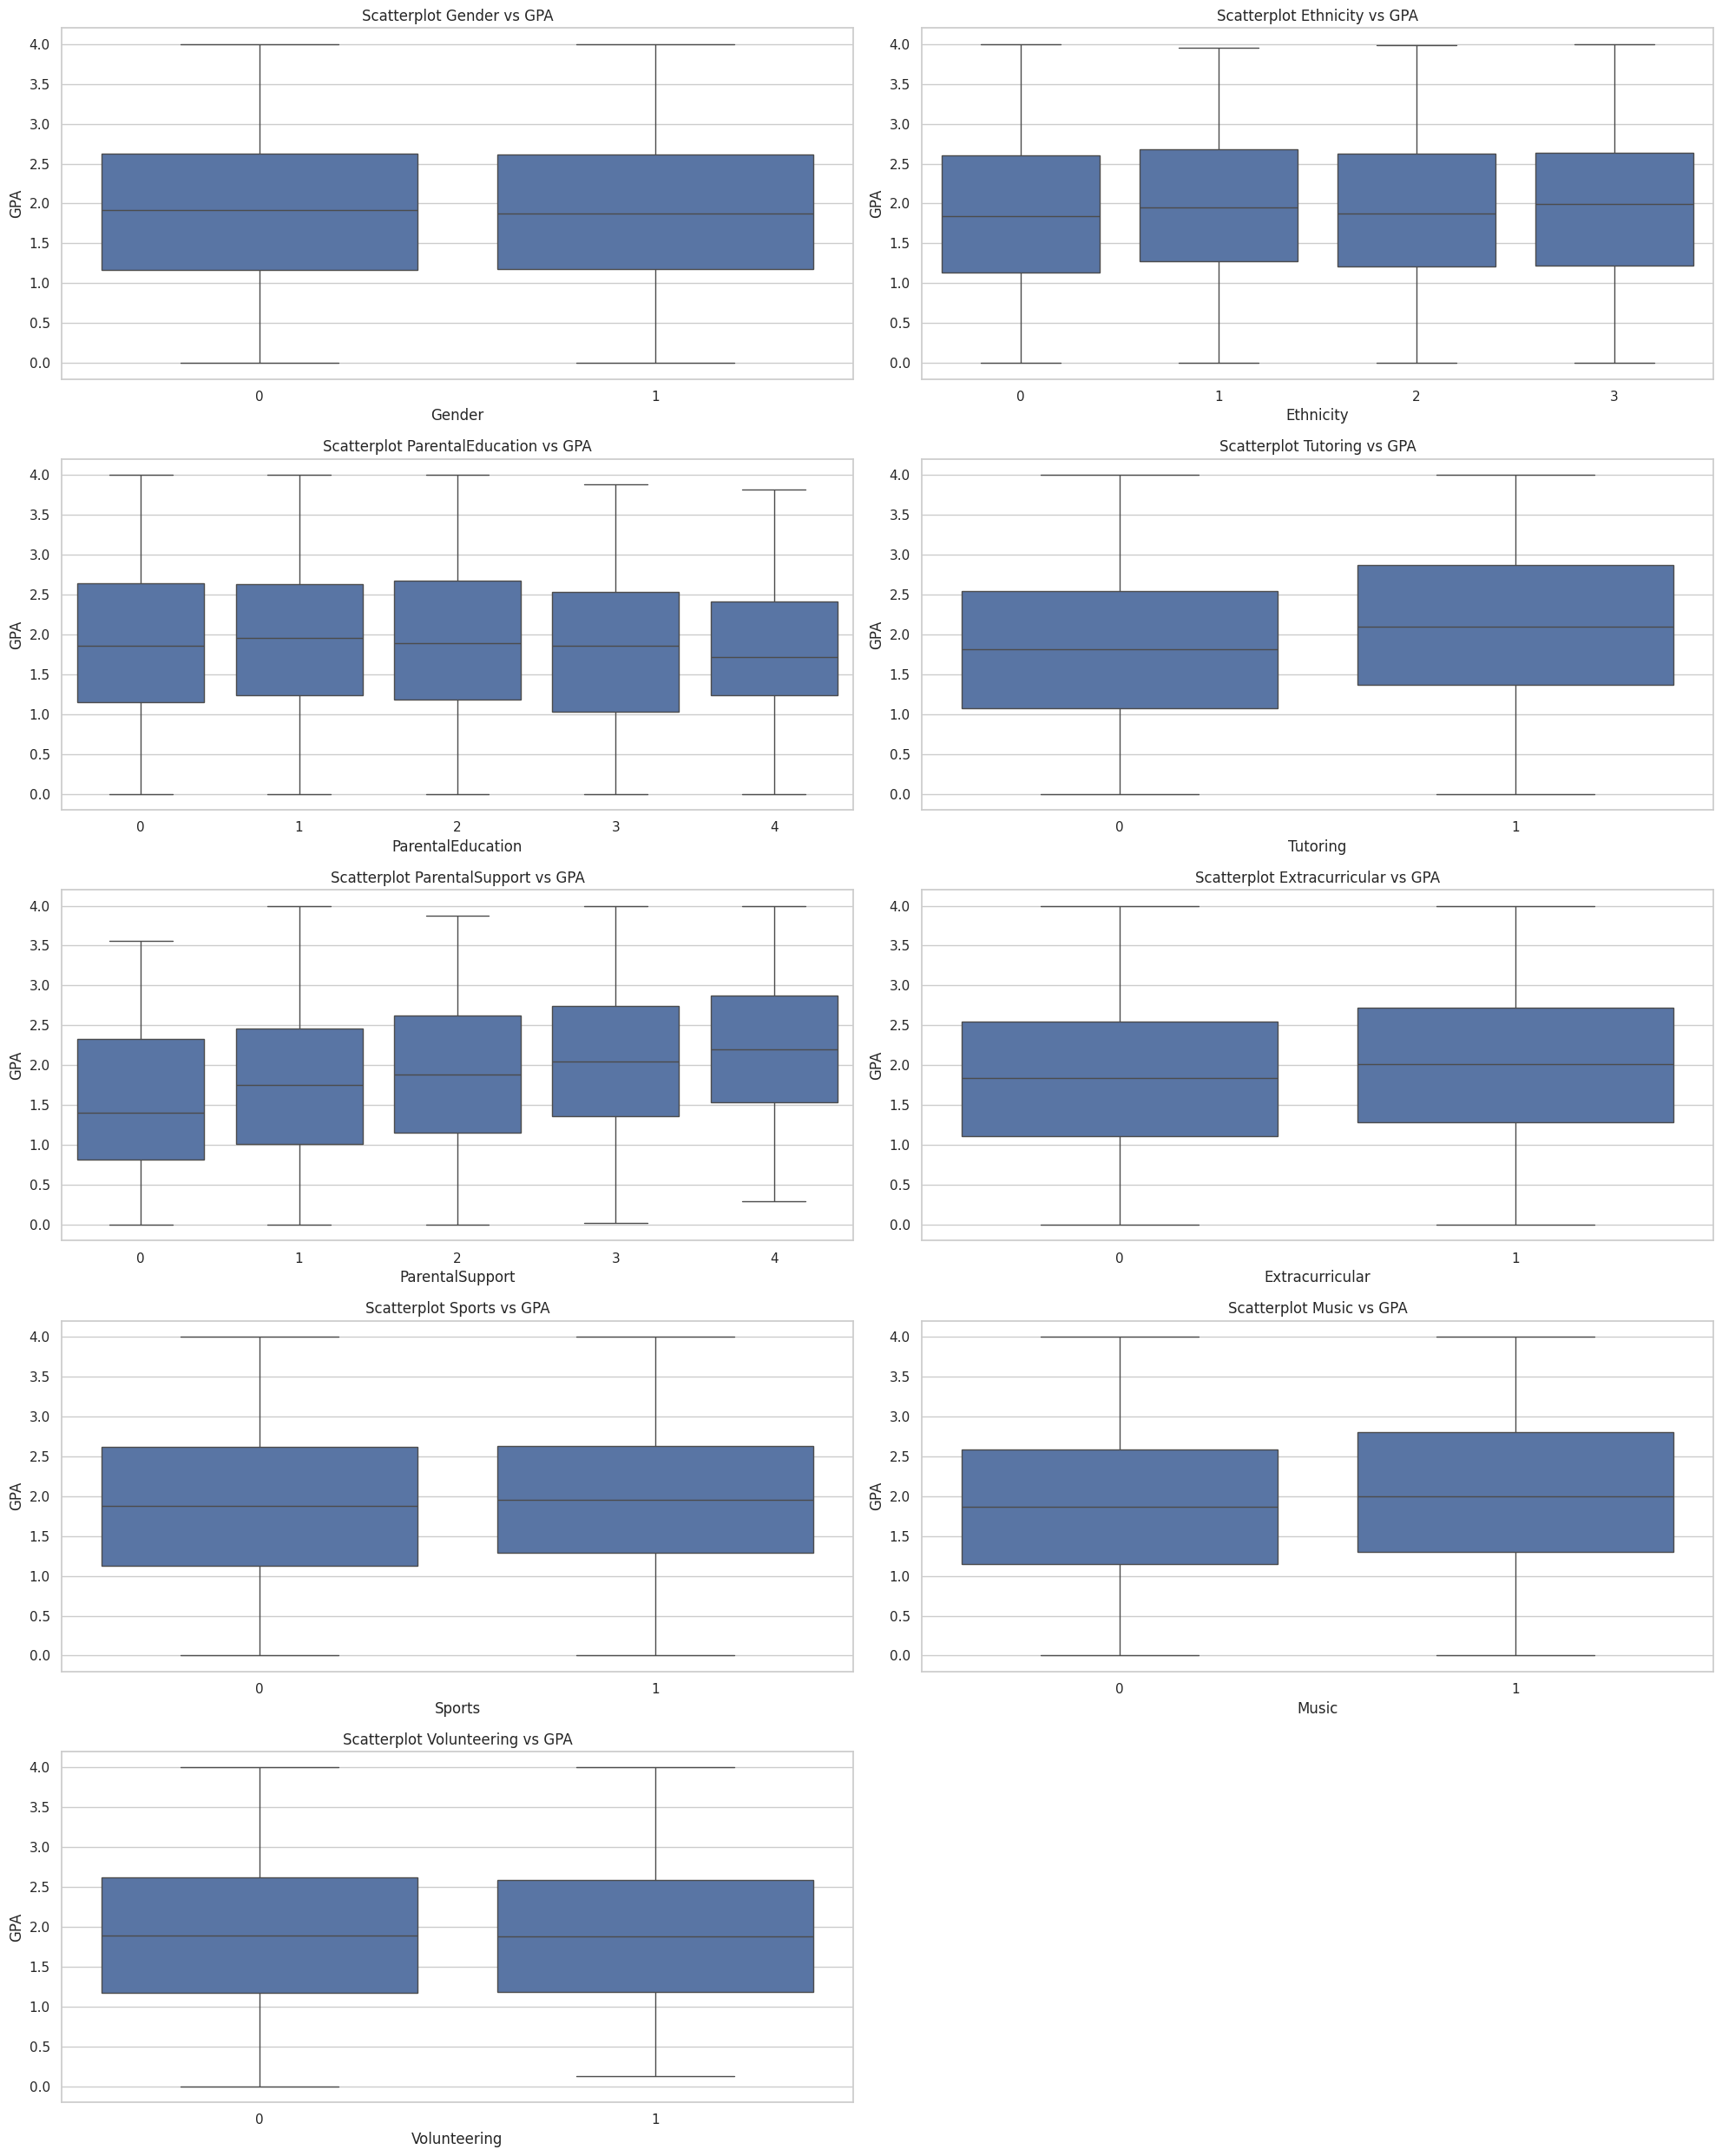

In [76]:
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_features):
  plt.subplot(5, 2, i + 1)
  sns.boxplot(x=student[col], y=student['GPA'])
  plt.title(f'Scatterplot {col} vs GPA')
plt.tight_layout()
plt.show()

**Insight:**

Dilihat dari hasil pengamatan dari analisis hubungan fitur kategorikal vs GPA:

- Fitur 'Tutoring' vs 'GPA', Siswa yang ikut tutoring cenderung punya median GPA lebih tinggi.
- Fitur 'ParentalSupport', Semakin tinggi dukungan orang tua (semakin ke kanan), GPA cenderung meningkat.
- Fitur 'Extracurricular', 'Music', 'Volunteering', Perbedaannya tidak terlalu besar, tapi tetap bisa dilihat variasinya.
- Fitur 'Gender' dan 'Ethnicity', Tidak terlihat perbedaan mencolok antara kategori terhadap GPA.
- Fitur 'ParentalEducation', Terlihat ada tren penurunan GPA pada level pendidikan orang tua yang lebih tinggi — bisa jadi faktor lain yang mempengaruhi.

In [77]:
# Cek rata-rata GPA tiap kategori
for col in categorical_features:
  mean_gpa = student.groupby(col)['GPA'].mean()
  print(f"Rata-rata GPA berdasarkan {col}:\n{mean_gpa}\n")

Rata-rata GPA berdasarkan Gender:
Gender
0    1.918679
1    1.894225
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Ethnicity:
Ethnicity
0    1.875905
1    1.946437
2    1.922125
3    1.947696
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan ParentalEducation:
ParentalEducation
0    1.893045
1    1.944022
2    1.929881
3    1.809082
4    1.815812
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Tutoring:
Tutoring
0    1.818968
1    2.108325
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan ParentalSupport:
ParentalSupport
0    1.540128
1    1.755700
2    1.884246
3    2.042409
4    2.191545
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Extracurricular:
Extracurricular
0    1.838316
1    2.015357
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Sports:
Sports
0    1.871240
1    1.986381
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Music:
Music
0    1.872969
1    2.041664
Name: GPA, dtype: float64

Rata-rata GPA berdasarkan Volunteering:
Volunteering
0

<ipython-input-77-f7b11e5b4d9b>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_gpa = student.groupby(col)['GPA'].mean()


**Insight:**

Dilihat dari hasil nilai rata-rata tersebut per variabel (fitur)
- 'Gender' Rata-rata GPA laki-laki (0) sedikit lebih tinggi daripada perempuan (1).
- 'Ethnicity'	Terdapat variasi kecil, tapi Ethnicity 1 dan 3 sedikit unggul di GPA.
- 'ParentalEducation'	Pendidikan orang tua tingkat 1 & 2, GPA anak lebih tinggi. Tingkat 3 & 4, lebih rendah.
- 'Tutoring'	Siswa yang ikut tutoring - GPA lebih tinggi secara signifikan (+0.29).
- 'ParentalSupport'	Dukungan orang tua sangat berkorelasi → Semakin tinggi support - GPA naik.
- 'Extracurricular'	Aktif ekskul - GPA lebih tinggi (+0.18).
- 'Sports'	Siswa yang olahraga - GPA lebih tinggi (+0.11).
- 'Music'	Bermusik - GPA lebih tinggi (+0.17).
- 'Volunteering'	Sedikit perbedaan (volunteer = 1.91 vs tidak = 1.90) - tidak signifikan.

Kesimpulannya, terdapat beberapa faktor yang berkorelasi positif terhadap GPA yaitu 'Tutoring, 'ParentalSupport', 'Extracurricular' activities (termasuk Sports & Music)

**Numerical Features**

Untuk mengamati hubungan antara fitur numerik, kita akan menggunakan fungsi pairplot(). Kita juga akan mengobservasi korelasi antara fitur numerik dengan fitur target menggunakan fungsi corr().

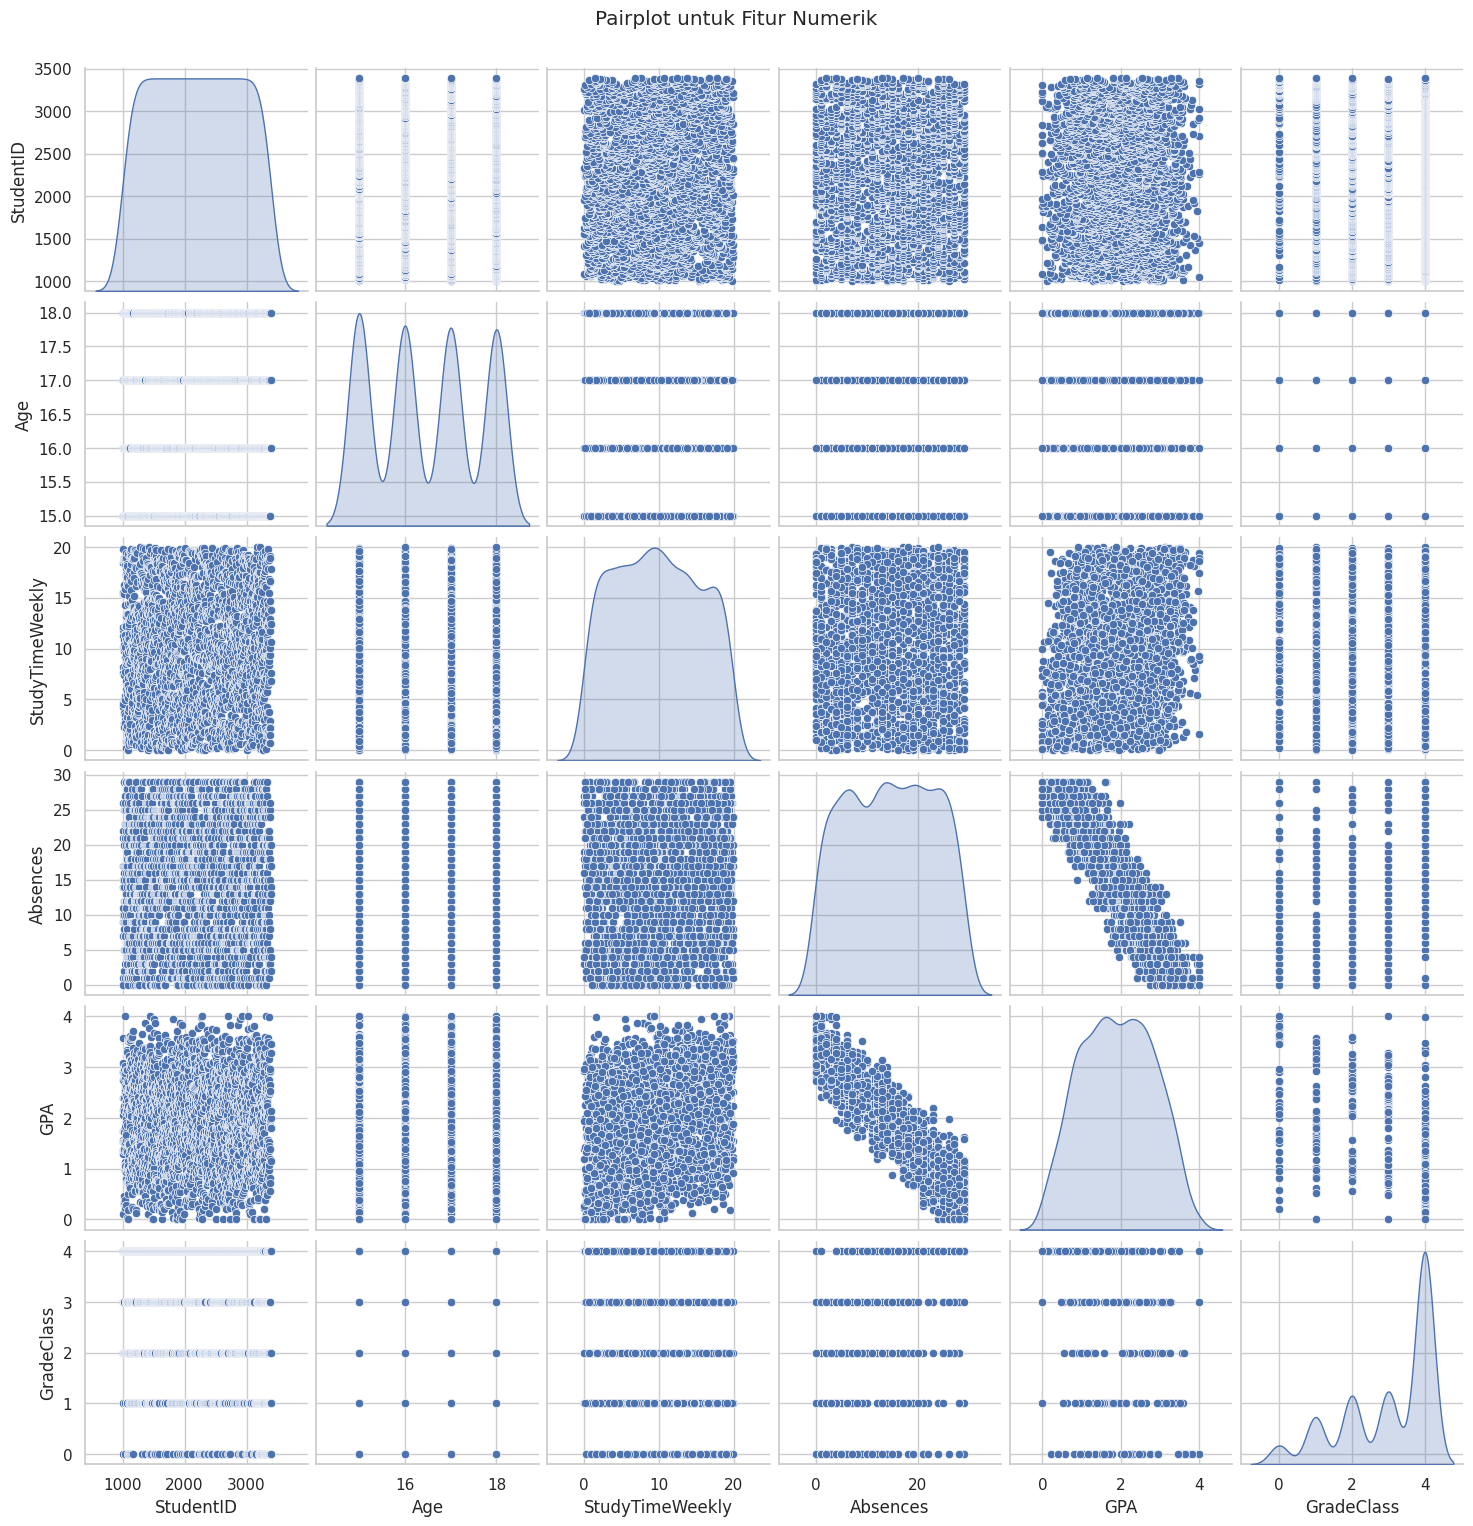

In [78]:
numerical_features = student.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numerical_features, diag_kind='kde')
plt.suptitle('Pairplot untuk Fitur Numerik', y=1.02)
plt.show()

**Insight:**

- Absences vs GPA: Terdapat hubungan negatif yang cukup jelas, dimana semakin sering siswa absen, semakin rendah nilai GPA mereka.

- StudyTimeWeekly vs GPA: Ada kecenderungan bahwa semakin banyak waktu belajar mingguan, nilai GPA cenderung meningkat, meskipun hubungan ini tidak terlalu kuat.

- GradeClass dan GPA: Nilai GradeClass cenderung turun seiring meningkatnya GPA, menunjukkan bahwa GPA yang tinggi berhubungan dengan peringkat kelas yang lebih baik.

**Correlation Matrix**

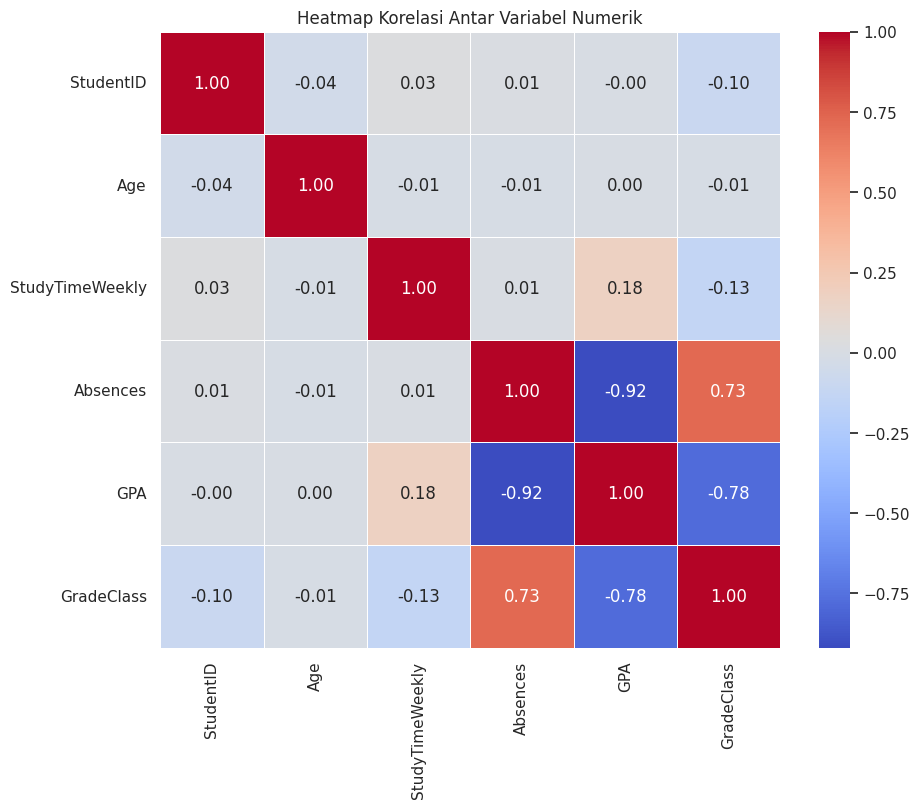

In [79]:
numerical_features = student.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numerical_features.corr()

# Visualisasi plot heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

**Insight:**

- GPA memiliki korelasi negatif yang sangat kuat terhadap Absences (-0.92). Artinya, semakin sering siswa absen, semakin rendah nilai GPA mereka.
- GradeClass juga berkorelasi negatif cukup kuat dengan GPA (-0.78). Hal ini masuk akal karena semakin tinggi nilai GPA, maka semakin besar kemungkinan siswa mendapatkan kelas nilai yang tinggi (GradeClass lebih rendah = lebih baik).
- Absences berkorelasi positif dengan GradeClass (0.73). Ini menunjukkan bahwa siswa yang sering absen cenderung mendapatkan kelas nilai yang lebih rendah (GradeClass lebih tinggi).
- Fitur lainnya seperti ParentalSupport, StudyTimeWeekly, dan ParentalEducation hanya menunjukkan korelasi lemah dengan GradeClass, sehingga kemungkinan pengaruhnya tidak terlalu signifikan secara langsung terhadap kelulusan siswa.
- StudentID dan Age tampaknkelihatannya tidak memiliki pengaruh berarti terhadap fitur target (GradeClass) karena nilai korelasinya mendekati nol.


In [80]:
# Hitung korelasi antar fitur numerik
correlation = numerical_features.corr()

# Korelasi dengan GPA saja
correlation_with_gpa = correlation["GPA"].sort_values(ascending=False)

# Tampilkan korelasi GPA
print("Korelasi dengan GPA:\n")
print(correlation_with_gpa)


Korelasi dengan GPA:

GPA                1.000000
StudyTimeWeekly    0.179275
Age                0.000275
StudentID         -0.002697
GradeClass        -0.782835
Absences          -0.919314
Name: GPA, dtype: float64


**Insight:**

- Absences (-0.919): Merupakan fitur yang paling berkorelasi negatif dengan GPA. Artinya, semakin sering siswa absen, semakin rendah GPA mereka. Ini adalah faktor risiko utama terhadap penurunan prestasi.

- GradeClass (-0.783): Juga memiliki korelasi negatif yang kuat. Siswa dengan GPA tinggi cenderung memiliki peringkat kelas yang lebih baik.

- StudyTimeWeekly (+0.179): Korelasi positif lemah. Ada indikasi bahwa semakin banyak waktu yang dihabiskan untuk belajar setiap minggu, GPA cenderung meningkat, meskipun tidak terlalu signifikan.

- Age (0.0003) dan StudentID (-0.0027): Tidak memiliki hubungan yang berarti terhadap GPA. Kemungkinan besar hanya bersifat administratif atau identitas siswa.

# Data Preparation



### Encoding Fitur Kategori

In [81]:
from sklearn.preprocessing import OneHotEncoder

# pisahkan target dan fitur
X = student.drop(columns=["GradeClass", "StudentID"])
y = student["GradeClass"]

# 2. One-hot encoding fitur kategorikal pakai get_dummies
categorical_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
                        'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
student.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


**Insight:**

 fitur kategorikal telah berhasil diubah menjadi format numerik menggunakan one-hot encoding.



In [82]:
student.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


**Insight:**

Setelah di cek kembali, Tidak ada missing values sama sekali (0 di semua kolom).

### Train-Test-Split

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Insight:**

Kode ini membagi dataset menjadi dua bagian: 80% untuk melatih model (X_train, y_train) dan 20% untuk menguji performa model pada data baru (X_test, y_test). Penggunaan random_state=42 memastikan hasil pembagian data konsisten setiap kali kode dijalankan, sehingga proyek Anda menjadi reproduktif.

### Standarisasi

In [84]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['Age', 'StudyTimeWeekly', 'Absences']
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])
X_train[numerical_features].head()

,Age,StudyTimeWeekly,Absences
642,1.372851,1.468159,1.105915
1752,-0.405858,-1.276773,0.516509
1401,0.483497,-1.103632,1.223797
2032,0.483497,1.068117,1.223797
990,-0.405858,-1.526524,0.516509


**Insight:**

Setelah distandardisasi menggunakan StandardScaler, nilai fitur numerik ('Age', 'StudyTimeWeekly', 'Absences') tidak lagi dalam satuan aslinya, melainkan direpresentasikan sebagai skor-z (z-scores) yang menunjukkan jarak setiap nilai dari rata-rata dalam satuan standar deviasi. Nilai positif berarti di atas rata-rata, negatif berarti di bawah rata-rata, dan nilai mendekati nol berarti dekat dengan rata-rata.

In [85]:
X_train[numerical_features].describe().round(4)

,Age,StudyTimeWeekly,Absences
count,1913.0000,1913.0000,1913.0000
mean,-0.0000,0.0000,-0.0000
std,1.0003,1.0003,1.0003
min,-1.2952,-1.7085,-1.7232
25%,-1.2952,-0.8401,-0.8981
50%,-0.4059,-0.0403,0.0450
75%,0.4835,0.8172,0.8702
max,1.3729,1.7926,1.6953


**Insight:**

Fitur-fitur numerik sekarang memiliki rata-rata mendekati nol dan standar deviasi mendekati satu, yang merupakan kondisi ideal untuk banyak algoritma machine learning yang sensitif terhadap skala data.

### Reduksi Dimensi dengan Principal Component Analysis (PCA)

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Jumlah komponen PCA:", X_train_pca.shape[1])

Jumlah komponen PCA: 15


**Insight:**

Setelah reduksi dimensi dengan PCA (n_components=0.95):

PCA secara otomatis memilih 15 komponen utama yang bisa menjelaskan 95% total variasi (informasi) dalam data.

# Model Development

Pada tahap ini, kita akan membangun model klasifikasi untuk memprediksi tingkat nilai akhir siswa (GradeClass 0-4). Kita akan mencoba beberapa algoritma dan mengevaluasi performanya.

Kita akan membuat tiga buah model machine learning dangan algoritma berikut:
1. Logistic Regression
2. Random Foreat
3. Gradient Boosting Classifier


###### Logistic Regression

In [87]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

###### Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

###### Gradient Boosting

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# Evaluasi

In [90]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 2))
print("Precision (weighted avg):", round(precision_score(y_test, y_pred_lr, average='weighted'), 2))
print("Recall (weighted avg):", round(recall_score(y_test, y_pred_lr, average='weighted'), 2))
print("F1 Score (weighted avg):", round(f1_score(y_test, y_pred_lr, average='weighted'), 2))
print()

print("Random Forest:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 2))
print("Precision (weighted avg):", round(precision_score(y_test, y_pred_rf, average='weighted'), 2))
print("Recall (weighted avg):", round(recall_score(y_test, y_pred_rf, average='weighted'), 2))
print("F1 Score (weighted avg):", round(f1_score(y_test, y_pred_rf, average='weighted'), 2))
print()

print("Logistic Regression:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 2))
print("Precision (weighted avg):", round(precision_score(y_test, y_pred_gb, average='weighted'), 2))
print("Recall (weighted avg):", round(recall_score(y_test, y_pred_gb, average='weighted'), 2))
print("F1 Score (weighted avg):", round(f1_score(y_test, y_pred_gb, average='weighted'), 2))
print()

Logistic Regression:
Accuracy: 0.74
Precision (weighted avg): 0.71
Recall (weighted avg): 0.74
F1 Score (weighted avg): 0.72

Random Forest:
Accuracy: 0.91
Precision (weighted avg): 0.91
Recall (weighted avg): 0.91
F1 Score (weighted avg): 0.9

Logistic Regression:
Accuracy: 0.9
Precision (weighted avg): 0.9
Recall (weighted avg): 0.9
F1 Score (weighted avg): 0.9



Berdasarkan hasil evaluasi dan metrik klasifikasi yang telah dilakukan, model yang paling optimal untuk digunakan dalam prediksi GradeClass adalah model Random Forest Anda (akibat akurasi 91%) secara langsung menjawab tujuan proyek dan berdampak positif pada business understanding.

1. Model membantu mengidentifikasi siswa yang berpotensi berjuang (GradeClass rendah) atau berpotensi sukses (GradeClass tinggi) berdasarkan faktor-faktor dalam data, yang merupakan inti tantangan institusi pendidikan.

2. Model berhasil membangun model klasifikasi multi-kelas yang akurat untuk memprediksi GradeClass, memungkinkan deteksi dini potensi performa akademik siswa

3. Adapun dampak dari setiap solusi steatment yaitu:

- Prediksi model memungkinkan guru fokus membimbing siswa berisiko, mengoptimalkan waktu mereka.
- Prediksi memungkinkan sekolah membuat program dukungan (intervensi/pengayaan) yang sangat spesifik dan tertarget pada kelompok siswa yang memerlukannya.
-  Informasi prediksi membantu orang tua lebih memahami potensi anak dan memberikan dukungan yang tepat di rumah.

